In [10]:
import pandas as pd
import os, sys

In [2]:
full_info_table = pd.read_csv('../data/INDI_database/INDI_info_full_cdr_info.tsv', sep='\t')
dupl_info_table = pd.read_csv('../data/INDI_database/INDI_info_full_cdr_info_dedup.tsv', sep='\t')

selected_ids_table = pd.read_csv('../data/INDI_database/dupl_INDI_passed_cleaned.tsv', sep='\t')

In [3]:
selected_full_info_table = pd.merge(selected_ids_table, full_info_table, how='left', left_on='pdb_id', right_on='PDBChain')
selected_full_info_table.drop(['pdb_id'], axis=1, inplace=True)

selected_full_info_table['PDB_ID'] = selected_full_info_table['PDBChain'].apply(lambda x: x[:4].upper())

In [24]:
selected_full_info_table.to_csv('../data/INDI_database/analysis/INDI_info_selected_cdr_full_info.tsv', index=False, sep='\t')

# Identified nanobodys with same CDR1, CDR2, CDR3

Find PDB with same CDR1, CDR2, CDR3

In [28]:

selected_info_table = selected_full_info_table.drop_duplicates(subset=['PDB_ID'], keep='first')    # Avoid same structure with different chain

grouped_selected_info_table = selected_info_table.groupby(["CDR1", "CDR2", "CDR3"])

group_counts = grouped_selected_info_table.size()

filtered_groups = group_counts[group_counts > 1]

In [29]:
# Step1: 按照 CDR1/CDR2/CDR3 分组，把 PDBChain 合并成逗号分隔字符串
agg_selected_info_table = selected_info_table.groupby(['CDR1', 'CDR2', 'CDR3']).agg(
    Member=('PDBChain', lambda x: ','.join(x)),
).reset_index()

# Step2: 过滤掉 Member 数量小于 2 的 group
# 这里通过逗号分隔统计有多少个 PDBChain
agg_selected_info_table = agg_selected_info_table[
    agg_selected_info_table['Member'].apply(lambda x: len(x.split(',')) >= 2)
]

# Step3: 保留每组的第一个 PDBChain 作为代表（Group Name）
merged_selected_info_table = pd.merge(
    selected_info_table.drop_duplicates(subset=['CDR1', 'CDR2', 'CDR3']),
    agg_selected_info_table,
    on=['CDR1', 'CDR2', 'CDR3']
)

# Step4: 导出 TSV
merged_selected_info_table.to_csv("../data/INDI_database/analysis/cdr_grouped_output.tsv", sep="\t", index=False)


1. Calculated cRMSD of CDR123 and connector
2. Calculated RMSD of full structure
3. Calculated structure embeddings of connector
4. Calculated correlation between structure embeddings and (c)RMSDs

nohup python ./scripts/compute_pairwise_distances.py --groups ./data/INDI_database/analysis/cdr_grouped_output.tsv --emb ./data/INDI_database/raw_embeddings.tsv --out ./data/group_comparison/cdr_grouped_pair_comparation.tsv --pdb_dir ./data/INDI_database/passed_pdbs/ --usalign_path /data1/dhuang/USalign/USalign > ./data/group_comparison/comparison.log &

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, t

def plot_corr(df, point_color, ci=0.95, figsize=(8, 6)):
    # Ensure columns exist
    if 'RMSD' not in df.columns or 'ConnectorDistance' not in df.columns:
        raise ValueError("Input TSV must contain columns named 'RMSD' and 'ConnectorDistance'.")

    # Convert to numeric and drop NA
    df['RMSD_num'] = pd.to_numeric(df['RMSD'], errors='coerce')
    df['Conn_num'] = pd.to_numeric(df['ConnectorDistance'], errors='coerce')
    df_clean = df.dropna(subset=['RMSD_num', 'Conn_num']).copy()

    x = df_clean['RMSD_num'].values
    y = df_clean['Conn_num'].values

    n = len(x)
    if n < 2:
        raise ValueError(f"Not enough valid pairs to compute correlations (n={n}).")

    # ---- Correlations ----
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    print(f"n = {n}")
    print(f"Pearson r = {pearson_r:.4f}, p = {pearson_p:.2e}")
    print(f"Spearman rho = {spearman_rho:.4f}, p = {spearman_p:.2e}")

    # ---- Scatter plot with linear fit and CI ----
    plt.figure(figsize=figsize)
    plt.scatter(x, y, alpha=0.7, c=point_color, )

    # Linear fit (ordinary least squares)
    coeff = np.polyfit(x, y, 1)
    slope, intercept = coeff[0], coeff[1]
    x_line = np.linspace(np.min(x), np.max(x), 200)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, color="red")

    # ---- Confidence interval calculation ----
    # Predicted values
    y_pred = slope * x + intercept
    residuals = y - y_pred
    dof = n - 2
    residual_var = np.sum(residuals**2) / dof

    # Standard error of the regression line
    x_mean = np.mean(x)
    se_line = np.sqrt(
        residual_var * (1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
    )

    # Critical t value
    alpha = 1 - ci
    t_val = t.ppf(1 - alpha/2, dof)

    ci_upper = y_line + t_val * se_line
    ci_lower = y_line - t_val * se_line

    # Plot CI as a shaded area
    plt.fill_between(x_line, ci_lower, ci_upper, color="red", alpha=0.1, label=f"{int(ci*100)}% CI")

    # Labels and title
    plt.xlabel('RMSD', fontsize=14)
    plt.ylabel('Connector embeddings distance', fontsize=14)

    # Annotations
    txt = (
        f"Pearson r = {pearson_r:.3f}\n"
        f"p = {pearson_p:.2e}\n\n"
        f"Spearman ρ = {spearman_rho:.3f}\n"
        f"p = {spearman_p:.2e}"
    )
    plt.gca().text(0.02, 0.98, txt, transform=plt.gca().transAxes,
                   verticalalignment='top', fontsize=12,
                   bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    plt.legend(frameon=False, fontsize=12)
    plt.tight_layout()

    return plt


n = 121
Pearson r = 0.7971, p = 7.85e-28
Spearman rho = 0.8490, p = 9.13e-35


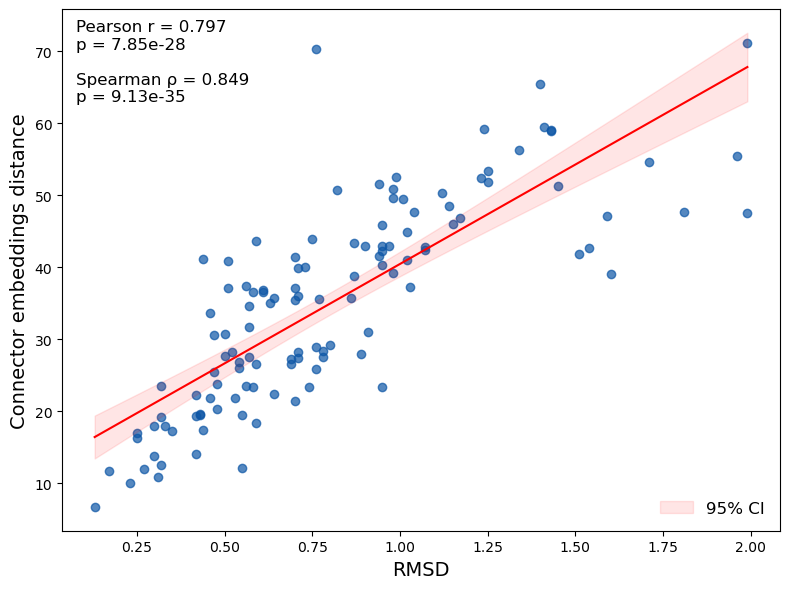

In [45]:
comparison_table = pd.read_csv('../data/group_comparison/cdr_grouped_pair_comparison.tsv', sep='\t')

comparison_table = comparison_table[comparison_table['RMSD'] < 3]    # Filter out RMSD > 3

point_color='#0D56A6' # Set the color of the points
comparison_plt = plot_corr(comparison_table, point_color=point_color, figsize=(8, 6))

comparison_plt.savefig('../figures/cdr_comparison_plot.png', dpi=600)

comparison_plt.show()

# Identified nanobodies with same framework (synthesis Nbs)

nohup python ./scripts/compute_pairwise_distances.py --groups ./data/INDI_database/synthesis_Nb_group.tsv --emb ./data/INDI_database/raw_embeddings.tsv --out ./data/group_comparison/synthesis_grouped_pair_comparation.tsv --pdb_dir ./data/INDI_database/passed_pdbs/ --usalign_path /data1/dhuang/USalign/USalign > ./data/group_comparison/synthesis_comparison.log &

In [20]:
syn_comparison_table = pd.read_csv('../data/group_comparison/synthesis_grouped_pair_comparation.tsv', sep='\t')

n = 16
Pearson r = 0.8294, p = 7.08e-05
Spearman rho = 0.8639, p = 1.61e-05


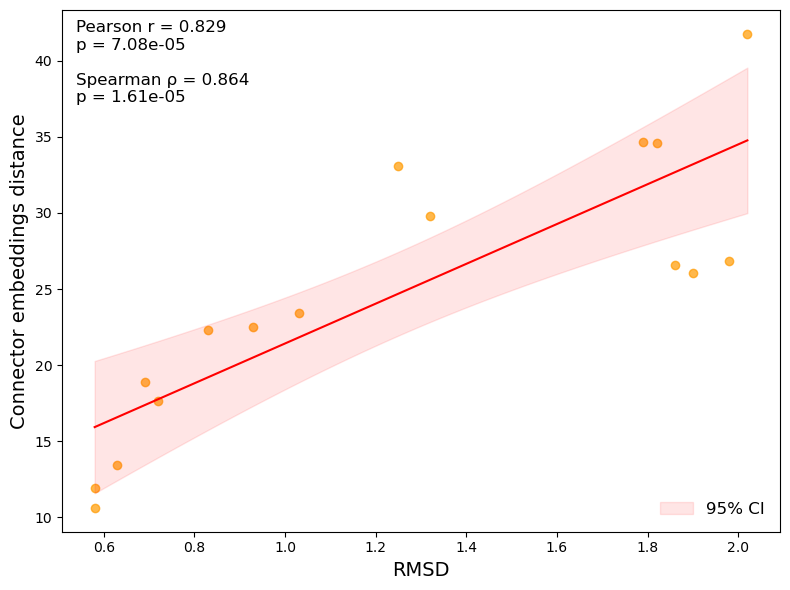

In [41]:
point_color='#FF9A00' # Set the color of the points
comparison_plt = plot_corr(syn_comparison_table, point_color=point_color, figsize=(8, 6))

comparison_plt.savefig('../figures/syn_comparison_plot.png', dpi=600)

comparison_plt.show()